In [1]:
import numpy as np
from meshparty import trimesh_io
import os
import trimesh
import matplotlib.pyplot as plt
import pymeshfix
from trimesh.repair import fix_winding, fix_normals
# ---------- Configuration ----------
SEG_VOL_PATH = "graphene://https://cave.fanc-fly.com/segmentation/table/wclee_mouse_spinalcord_cltmr"
CACHE_DIR = "/Users/wangchu/connectivity_analysis/meshes"
RADIUS_THRESH = 20000  # in nanometers (15 µm radius for bounding box)
VOXEL_RES = [32, 32, 45]  # nanometers per voxel (assumed input resolution)
# -----------------------------------



/Users/wangchu/opt/anaconda3/lib/python3.8/site-packages/python_jsonschema_objects/__init__.py:113: UserWarning: Schema id not specified. Defaulting to 'self'
  warnings.warn("Schema id not specified. Defaulting to 'self'")


import json
import csv

# Recursive function to find all "point" entries
def find_points(obj, points):
    if isinstance(obj, dict):
        for key, value in obj.items():
            if key == "point" and isinstance(value, list) and len(value) == 3:
                point_str = ",".join(str(v) for v in value)
                points.append(point_str)
            else:
                find_points(value, points)
    elif isinstance(obj, list):
        for item in obj:
            find_points(item, points)

# Load JSON file
with open("/Users/wangchu/Downloads/in_soma_quantification.json", "r") as f:
    data = json.load(f)

# Extract points
points = []
find_points(data, points)

# Write to CSV (single column)
with open("in_soma_coord.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["point"])  # single column header
    for point in points:
        writer.writerow([point])  # still a list, one column per row

print(f"Extracted {len(points)} points to output.csv")


In [2]:
import pandas as pd
import numpy as np
df = pd.read_csv('in_soma_coord.csv')

In [3]:
import cloudvolume
spinalcord_seg = cloudvolume.CloudVolume(SEG_VOL_PATH, 
                                   use_https=True,
                                   mip=(32,32,45), 
                                   agglomerate=True, # for rootids
                                   progress=False)

In [4]:
#df = pd.read_csv('pn_soma_coord.csv')
root_ids = []
results=[]
def get_seg_id_from_coord(coord, seg_mip=(32,32,45), coordinate_mip=(32,32,45)):

    mip_scale = np.array(seg_mip)/np.array(coordinate_mip)
    seg_coord = (coord[0]//mip_scale[0], coord[1]//mip_scale[1], coord[2]//mip_scale[2])
    
    voxel_seg_id = spinalcord_seg[seg_coord] # segmentation ID of neuron coordinate
    return voxel_seg_id

for idx, row in df.iterrows():
    coord_str = str(row['point'])  # Note: keeping the misspelling as it appears in the CSV
    try:
        # Parse coordinates, handling both integer and float formats
        coords = [float(x.strip()) for x in coord_str.split(',')]
        coords = [int(round(x)) for x in coords]  # Round and convert to integers
        print(coords)
        root_id = get_seg_id_from_coord(coords)
        root_ids.append(root_id)  # Add root_id to list (will include None values)
        
        if root_id is not None:
            results.append({
                'x': coords[0],
                'y': coords[1],
                'z': coords[2],
                'root_id': root_id
            })
            print(f"Processed coordinate {coords}: root_id = {root_id}")
        else:
            print(f"No root ID found for coordinate {coords}")
    except Exception as e:
        print(f"Error parsing coordinate string {coord_str}: {str(e)}")
        root_ids.append(None)  # Add None for failed coordinates

# Print all root IDs
print("\nAll root IDs (including None values):")
print(root_ids)
# Convert results to DataFrame and save
results_df = pd.DataFrame(results)

[29596, 2493, 816]
Processed coordinate [29596, 2493, 816]: root_id = [[[[720575940911002785]]]]
[29097, 2695, 754]
Processed coordinate [29097, 2695, 754]: root_id = [[[[720575940881910011]]]]
[28068, 2542, 754]
Processed coordinate [28068, 2542, 754]: root_id = [[[[720575940890634484]]]]
[27218, 2599, 760]
Processed coordinate [27218, 2599, 760]: root_id = [[[[720575940910500889]]]]
[26715, 2488, 1653]
Processed coordinate [26715, 2488, 1653]: root_id = [[[[720575940878957108]]]]
[24276, 2383, 1624]
Processed coordinate [24276, 2383, 1624]: root_id = [[[[720575940898475005]]]]
[23641, 2173, 1600]
Processed coordinate [23641, 2173, 1600]: root_id = [[[[720575940951332903]]]]
[21965, 2488, 1600]
Processed coordinate [21965, 2488, 1600]: root_id = [[[[720575940897341954]]]]
[21813, 2702, 1600]
Processed coordinate [21813, 2702, 1600]: root_id = [[[[720575940868451736]]]]
[16149, 2357, 1723]
Processed coordinate [16149, 2357, 1723]: root_id = [[[[720575940916299357]]]]
[15501, 2724, 1720

In [20]:
results_df

,x,y,z,root_id
0,10589,2669,1256,[[[[720575940886574602]]]]
1,8963,2431,2941,[[[[720575940868396952]]]]
2,13291,2906,4030,[[[[720575940882393805]]]]
3,23718,2529,206,[[[[720575940921478163]]]]
4,27021,2337,1653,[[[[720575940887194266]]]]
5,29497,2432,3943,[[[[720575940901717479]]]]
6,37039,3103,1772,[[[[720575940869352923]]]]
7,40725,3082,1821,[[[[720575940903113149]]]]
8,19928,2288,2179,[[[[720575940902518994]]]]
9,18601,2355,1102,[[[[720575940889952699]]]]


In [21]:
results = [
    ([row['x'], row['y'], row['z']], row['root_id'][0][0][0][0])
    for _, row in results_df.iterrows()
]


In [5]:
results

[{'x': 29596,
  'y': 2493,
  'z': 816,
  'root_id': VolumeCutout([[[[720575940911002785]]]], dtype=uint64)},
 {'x': 29097,
  'y': 2695,
  'z': 754,
  'root_id': VolumeCutout([[[[720575940881910011]]]], dtype=uint64)},
 {'x': 28068,
  'y': 2542,
  'z': 754,
  'root_id': VolumeCutout([[[[720575940890634484]]]], dtype=uint64)},
 {'x': 27218,
  'y': 2599,
  'z': 760,
  'root_id': VolumeCutout([[[[720575940910500889]]]], dtype=uint64)},
 {'x': 26715,
  'y': 2488,
  'z': 1653,
  'root_id': VolumeCutout([[[[720575940878957108]]]], dtype=uint64)},
 {'x': 24276,
  'y': 2383,
  'z': 1624,
  'root_id': VolumeCutout([[[[720575940898475005]]]], dtype=uint64)},
 {'x': 23641,
  'y': 2173,
  'z': 1600,
  'root_id': VolumeCutout([[[[720575940951332903]]]], dtype=uint64)},
 {'x': 21965,
  'y': 2488,
  'z': 1600,
  'root_id': VolumeCutout([[[[720575940897341954]]]], dtype=uint64)},
 {'x': 21813,
  'y': 2702,
  'z': 1600,
  'root_id': VolumeCutout([[[[720575940868451736]]]], dtype=uint64)},
 {'x': 16149,


In [68]:
pn_id = [item[1] for item in results]

In [72]:
len(pn_id)

33

In [23]:
# Example input: list of tuples (coord_voxel, root_id)
# Each coordinate is in (x, y, z) voxel space at 4nm x/y, 45nm z resolution
#soma_list = [
#    ([19124, 2529, 1956], 720575940899191123),  # (x, y, z), root_id
#   ([25470, 2722, 2408], 720575940870172803),
#    ([26748, 2542, 1701], 720575940878957108),
#    ([31427, 2695, 873], 720575940894563284),
#    ([30327, 2744, 1669], 720575940883198167),
#    ([37039, 3103, 1772], 720575940869352923)
#]

# Setup MeshMeta
mm = trimesh_io.MeshMeta(
    cv_path=SEG_VOL_PATH,
    disk_cache_path=CACHE_DIR,
    map_gs_to_https=True
)

import numpy as np
from meshparty import trimesh_io
import random

# Constants

MIN_RANDOM_NUM_VERTICE_SAMPLES = 2000

In [24]:
# ------------ Remapping Helper ------------
def build_submesh(vertices, faces, selected_indices):
    index_map = {old_idx: new_idx for new_idx, old_idx in enumerate(selected_indices)}
    selected_set = set(selected_indices)

    remapped_faces = []
    for face in faces:
        if all(v in selected_set for v in face):
            remapped_faces.append([index_map[v] for v in face])

    if not remapped_faces:
        return None

    new_vertices = vertices[selected_indices]
    new_faces = np.array(remapped_faces, dtype=np.int32)
    return trimesh_io.Mesh(vertices=new_vertices, faces=new_faces)
# -------------------------------------------

# ------------ Main Function ------------
def compute_soma_volume_and_plot(coord_voxel, root_id, show_plot=True, save_path=None):
    try:
        soma_coord = np.array([
            coord_voxel[0] * VOXEL_RES[0],
            coord_voxel[1] * VOXEL_RES[1],
            coord_voxel[2] * VOXEL_RES[2]
        ])

        print(f"\nLoading mesh for root ID {root_id}...")
        seg_mesh = mm.mesh(seg_id=root_id)
        vertices = seg_mesh.vertices
        faces = seg_mesh.faces
        print(f"- Mesh has {len(vertices)} vertices and {len(faces)} faces")

        # Step 1: Find nearby vertices
        vertex_indices_filtered = [
            i for i, v in enumerate(vertices)
            if np.linalg.norm(v - soma_coord) < RADIUS_THRESH
        ]

        if len(vertex_indices_filtered) == 0:
            print(f"⚠️ No vertices found near soma {root_id}")
            return 0.0

        # Step 2: Build remapped submesh
        soma_mesh = build_submesh(vertices, faces, vertex_indices_filtered)
        print("Watertight:", soma_mesh.is_watertight)
        print("Signed volume (nm³):", soma_mesh.volume)
        print("Convex hull volume (nm³):", soma_mesh.bounding_box_oriented.volume)

        if soma_mesh is None:
            print(f"⚠️ No valid faces for root_id={root_id}")
            return 0.0


        # Step 1: Split into connected components
        components = soma_mesh.split(only_watertight=False)

        # Step 2: Choose the largest (by number of faces)
        largest_component = max(components, key=lambda m: len(m.faces))

        # Step 3: Fill holes to try to make it watertight
        if not largest_component.is_watertight:
            print("🔧 Attempting to fill holes...")

        # Get vertices and faces from the non-watertight mesh
        v = largest_component.vertices
        f = largest_component.faces

       # Use PyMeshFix to repair
        meshfix = pymeshfix.MeshFix(v, f)
        meshfix.repair(joincomp=True, remove_smallest_components=False, verbose=True)

       # Convert back to Trimesh
        repaired = trimesh.Trimesh(meshfix.v, meshfix.f, process=False)

        # Check result
        print("Watertight after PyMeshFix:", repaired.is_watertight)

       # Step 4: Check again
        if not repaired.is_watertight:
            print("⚠️ Still not watertight after repair — using convex hull.")
#            volume_um3 = repaired.convex_hull.volume / 1e9
        else:
            volume_um3 = repaired.volume / 1e9



        print(f"✅ Soma at {coord_voxel} (root_id={root_id}) → Volume: {volume_um3:.3f} µm³")

        # Step 4: Plot 2D projection
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(repaired.vertices[:, 0], repaired.vertices[:, 1], s=1, c='black')
        ax.set_aspect('equal')
        ax.set_title(f"largest_component (root_id={root_id})")
        ax.set_xlabel("X (nm)")
        ax.set_ylabel("Y (nm)")

        if save_path:
            plt.savefig(save_path, dpi=300)
            print(f"🖼️ Saved plot to {save_path}")
        if show_plot:
            plt.show()
        else:
            plt.close()

        return volume_um3

    except Exception as e:
        print(f"❌ Error processing soma {root_id}: {e}")
        return None
# -------------------------------------------



Loading mesh for root ID 720575940886574602...


- Mesh has 1156859 vertices and 2299223 faces
Watertight: False
Signed volume (nm³): 1290077972758.0
Convex hull volume (nm³): 10006273358493.047
🔧 Attempting to fill holes...
Patching holes...
Patched 31 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [10589, 2669, 1256] (root_id=720575940886574602) → Volume: 2158.354 µm³


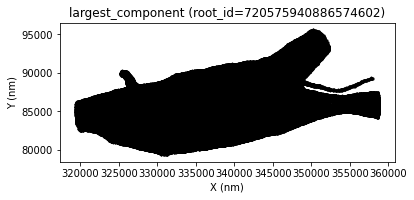


Loading mesh for root ID 720575940868396952...


- Mesh has 1768960 vertices and 3516601 faces
Watertight: False
Signed volume (nm³): 3505524279959.1665
Convex hull volume (nm³): 16514879826165.496
🔧 Attempting to fill holes...
Patching holes...
Patched 8 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [8963, 2431, 2941] (root_id=720575940868396952) → Volume: 2995.423 µm³


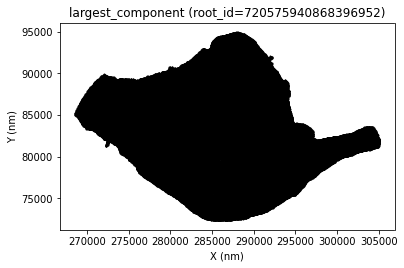


Loading mesh for root ID 720575940882393805...


- Mesh has 1346786 vertices and 2664053 faces
Watertight: False
Signed volume (nm³): -20521272105765.664
Convex hull volume (nm³): 9810224132104.354
🔧 Attempting to fill holes...
Patching holes...
Patched 36 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [13291, 2906, 4030] (root_id=720575940882393805) → Volume: 1402.075 µm³


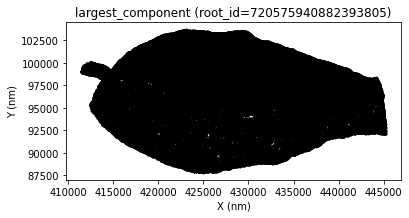


Loading mesh for root ID 720575940921478163...


- Mesh has 1394618 vertices and 2775055 faces
Watertight: False
Signed volume (nm³): 3612710868512.833
Convex hull volume (nm³): 9180065146171.143
🔧 Attempting to fill holes...
Patching holes...
Patched 5 holes
Fixing degeneracies and intersections
Patching holes...
Patched 1 holes
Performing final check...


Watertight after PyMeshFix: False
⚠️ Still not watertight after repair — using convex hull.
❌ Error processing soma 720575940921478163: local variable 'volume_um3' referenced before assignment

Loading mesh for root ID 720575940887194266...


- Mesh has 990178 vertices and 1973276 faces
Watertight: False
Signed volume (nm³): 1005079301305.5
Convex hull volume (nm³): 9769572124031.465
🔧 Attempting to fill holes...
Patching holes...
Patched 19 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [27021, 2337, 1653] (root_id=720575940887194266) → Volume: 1557.948 µm³


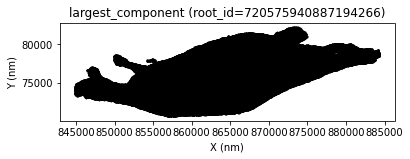


Loading mesh for root ID 720575940901717479...


- Mesh has 1172502 vertices and 2329908 faces
Watertight: False
Signed volume (nm³): -1789191853608.0
Convex hull volume (nm³): 11758229387105.053
🔧 Attempting to fill holes...
Patching holes...
Patched 3 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [29497, 2432, 3943] (root_id=720575940901717479) → Volume: 1450.293 µm³


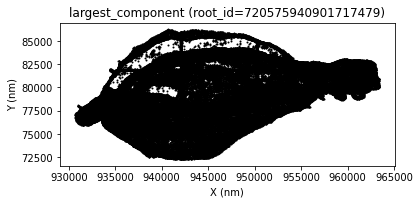


Loading mesh for root ID 720575940869352923...
- Mesh has 2816428 vertices and 5612311 faces
Watertight: False
Signed volume (nm³): -4653642300931.333
Convex hull volume (nm³): 15799247935674.953
🔧 Attempting to fill holes...
Patching holes...
Patched 9 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [37039, 3103, 1772] (root_id=720575940869352923) → Volume: 2531.167 µm³


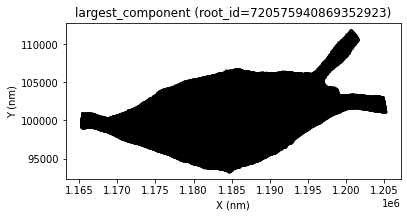


Loading mesh for root ID 720575940903113149...


- Mesh has 2257118 vertices and 4499148 faces
Watertight: False
Signed volume (nm³): 434485430128.8333
Convex hull volume (nm³): 25061203788363.535
🔧 Attempting to fill holes...
Patching holes...
Patched 23 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [40725, 3082, 1821] (root_id=720575940903113149) → Volume: 2403.954 µm³


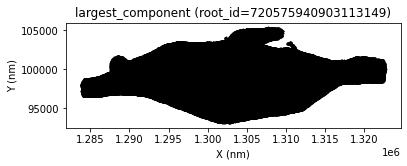


Loading mesh for root ID 720575940902518994...


- Mesh has 1295825 vertices and 2574355 faces
Watertight: False
Signed volume (nm³): 9423970018188.5
Convex hull volume (nm³): 11435391477264.096
🔧 Attempting to fill holes...
Patching holes...
Patched 243 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [19928, 2288, 2179] (root_id=720575940902518994) → Volume: 2462.607 µm³


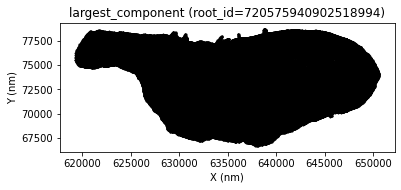


Loading mesh for root ID 720575940889952699...


- Mesh has 803030 vertices and 1581881 faces
Watertight: False
Signed volume (nm³): -9211636619602.332
Convex hull volume (nm³): 10499203000576.662
🔧 Attempting to fill holes...
Patching holes...
Patched 73 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [18601, 2355, 1102] (root_id=720575940889952699) → Volume: 2268.273 µm³


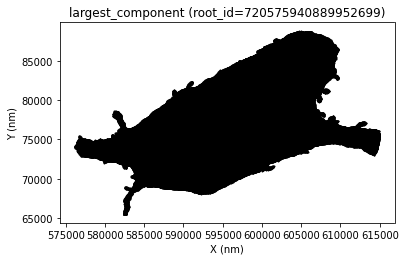


Loading mesh for root ID 720575940881974650...


- Mesh has 1944872 vertices and 3872576 faces
Watertight: False
Signed volume (nm³): -2807544944372.833
Convex hull volume (nm³): 18771795593474.305
🔧 Attempting to fill holes...
Patching holes...
Patched 25 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [18283, 2329, 1832] (root_id=720575940881974650) → Volume: 1799.167 µm³


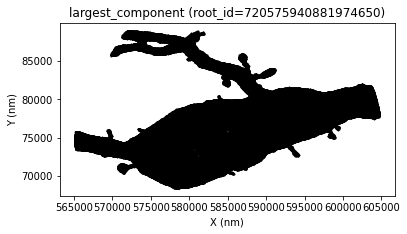


Loading mesh for root ID 720575940914014910...


- Mesh has 1156938 vertices and 2299745 faces
Watertight: False
Signed volume (nm³): -360571299684.0
Convex hull volume (nm³): 15489159393496.418
🔧 Attempting to fill holes...
Patching holes...
Patched 632 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [7867, 2314, 1940] (root_id=720575940914014910) → Volume: 2351.378 µm³


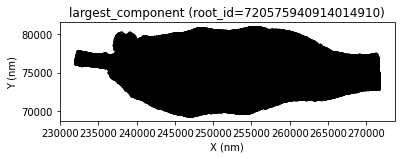


Loading mesh for root ID 720575940890704372...


- Mesh has 702259 vertices and 1392399 faces
Watertight: False
Signed volume (nm³): 2190131584220.0
Convex hull volume (nm³): 7861304293269.731
🔧 Attempting to fill holes...
Patching holes...
Patched 177 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [6527, 2365, 1816] (root_id=720575940890704372) → Volume: 2365.546 µm³


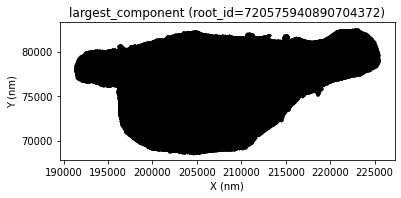


Loading mesh for root ID 720575940896702138...


- Mesh has 953488 vertices and 1895463 faces
Watertight: False
Signed volume (nm³): 1326031992121.5
Convex hull volume (nm³): 16941810135815.832
🔧 Attempting to fill holes...
Patching holes...
Patched 59 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [5690, 2452, 2570] (root_id=720575940896702138) → Volume: 1761.533 µm³


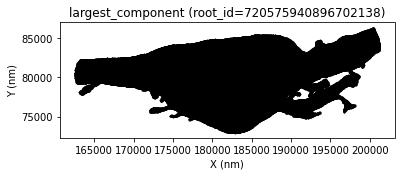


Loading mesh for root ID 720575940879773686...


- Mesh has 1109530 vertices and 2206865 faces
Watertight: False
Signed volume (nm³): -3063962397997.833
Convex hull volume (nm³): 7483169397345.048
🔧 Attempting to fill holes...
Patching holes...
Patched 8 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [17821, 2946, 292] (root_id=720575940879773686) → Volume: 1670.551 µm³


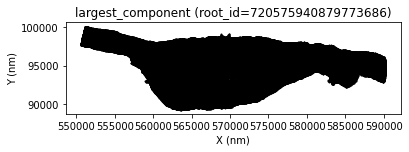


Loading mesh for root ID 720575940905050934...


- Mesh has 1023106 vertices and 2031708 faces
Watertight: False
Signed volume (nm³): -741783471631.3333
Convex hull volume (nm³): 13161235736792.248
🔧 Attempting to fill holes...
Patching holes...
Patched 21 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [25365, 2196, 2934] (root_id=720575940905050934) → Volume: 1859.138 µm³


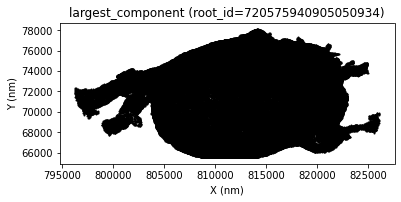


Loading mesh for root ID 720575940913491825...


- Mesh has 1078615 vertices and 2145962 faces
Watertight: False
Signed volume (nm³): -4437073226539.5
Convex hull volume (nm³): 10086824178940.498
🔧 Attempting to fill holes...
Patching holes...
Patched 296 holes
Fixing degeneracies and intersections
Patching holes...
Patched 1 holes
Performing final check...


Watertight after PyMeshFix: False
⚠️ Still not watertight after repair — using convex hull.
❌ Error processing soma 720575940913491825: local variable 'volume_um3' referenced before assignment

Loading mesh for root ID 720575940898677394...


- Mesh has 694555 vertices and 1379205 faces
Watertight: False
Signed volume (nm³): 11881222290197.832
Convex hull volume (nm³): 19126997440664.98
🔧 Attempting to fill holes...
Patching holes...
Patched 44 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [30229, 2492, 752] (root_id=720575940898677394) → Volume: 1905.859 µm³


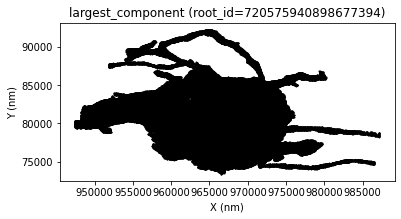


Loading mesh for root ID 720575940898677394...
- Mesh has 694555 vertices and 1379205 faces
Watertight: False
Signed volume (nm³): 11320243388475.666
Convex hull volume (nm³): 19813055048493.62
🔧 Attempting to fill holes...
Patching holes...
Patched 45 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [30231, 2488, 768] (root_id=720575940898677394) → Volume: 1915.576 µm³


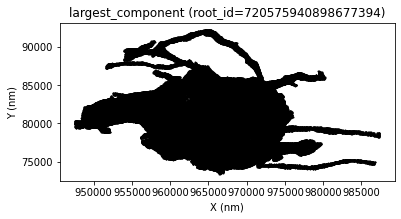


Loading mesh for root ID 720575940963340820...


- Mesh has 872644 vertices and 1733852 faces
Watertight: False
Signed volume (nm³): 1587256335591.3333
Convex hull volume (nm³): 10027341027818.139
🔧 Attempting to fill holes...
Patching holes...
Patched 259 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [34791, 2790, 917] (root_id=720575940963340820) → Volume: 2075.529 µm³


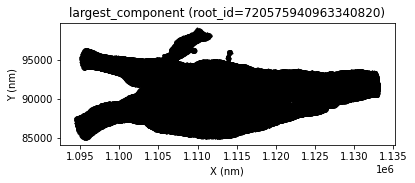


Loading mesh for root ID 720575940897341698...


- Mesh has 697361 vertices and 1382230 faces
Watertight: False
Signed volume (nm³): 1302789588917.0
Convex hull volume (nm³): 11431367076960.617
🔧 Attempting to fill holes...
Patching holes...
Patched 23 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [43676, 3371, 1228] (root_id=720575940897341698) → Volume: 1733.245 µm³


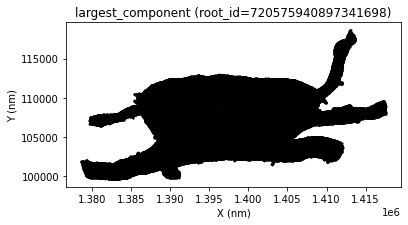


Loading mesh for root ID 720575940884015788...


- Mesh has 886569 vertices and 1756974 faces
Watertight: False
Signed volume (nm³): -76801347423.0
Convex hull volume (nm³): 9440741014062.566
🔧 Attempting to fill holes...
Patching holes...
Patched 6 holes
Fixing degeneracies and intersections
Patching holes...
Patched 1 holes
Performing final check...
Watertight after PyMeshFix: False
⚠️ Still not watertight after repair — using convex hull.
❌ Error processing soma 720575940884015788: local variable 'volume_um3' referenced before assignment

Loading mesh for root ID 720575940894563284...
- Mesh has 702374 vertices and 1397142 faces
Watertight: False
Signed volume (nm³): -28029884242.833332
Convex hull volume (nm³): 16055162616505.291
🔧 Attempting to fill holes...
Patching holes...
Patched 18 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [31454, 2679, 832] (root_id=720575940894563284) → Volume: 1482.281 µm³


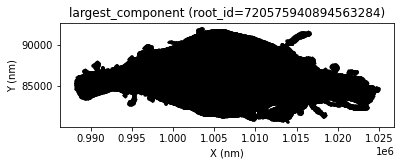


Loading mesh for root ID 720575940883198167...
- Mesh has 1076643 vertices and 2145901 faces
Watertight: False
Signed volume (nm³): 14100933068297.666
Convex hull volume (nm³): 8817475487898.578
🔧 Attempting to fill holes...
Patching holes...
Patched 4 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [30373, 2720, 1635] (root_id=720575940883198167) → Volume: 1585.434 µm³


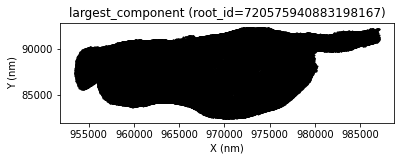


Loading mesh for root ID 720575940909802419...


- Mesh has 671885 vertices and 1335511 faces
Watertight: False
Signed volume (nm³): -11401698423664.5
Convex hull volume (nm³): 12816103349233.107
🔧 Attempting to fill holes...
Patching holes...
Patched 86 holes
Fixing degeneracies and intersections
Patching holes...
Patched 1 holes
Performing final check...


Watertight after PyMeshFix: False
⚠️ Still not watertight after repair — using convex hull.
❌ Error processing soma 720575940909802419: local variable 'volume_um3' referenced before assignment

Loading mesh for root ID 720575940884939979...


- Mesh has 1291474 vertices and 2571558 faces
Watertight: False
Signed volume (nm³): 444392149900.0
Convex hull volume (nm³): 10234539770266.258
🔧 Attempting to fill holes...
Patching holes...
Patched 132 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [28612, 2537, 2570] (root_id=720575940884939979) → Volume: 2070.783 µm³


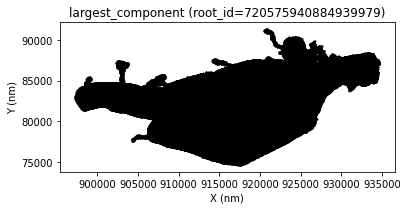


Loading mesh for root ID 720575940865160474...


- Mesh has 612728 vertices and 1217329 faces
Watertight: False
Signed volume (nm³): 5284419851381.166
Convex hull volume (nm³): 20694974629940.977
🔧 Attempting to fill holes...
Patching holes...
Patched 14 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [22447, 2737, 796] (root_id=720575940865160474) → Volume: 2359.055 µm³


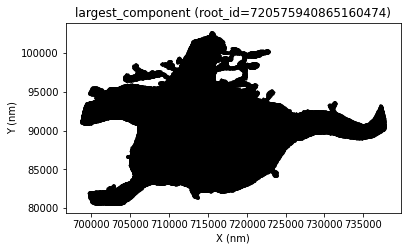


Loading mesh for root ID 720575940915676096...


- Mesh has 1715876 vertices and 3405056 faces
Watertight: False
Signed volume (nm³): 17530546731828.0
Convex hull volume (nm³): 7442098669499.469
🔧 Attempting to fill holes...
Patching holes...
Patched 32 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [23636, 2709, 1141] (root_id=720575940915676096) → Volume: 2283.986 µm³


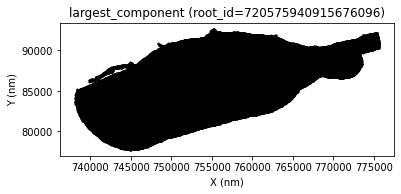


Loading mesh for root ID 720575940924431938...


- Mesh has 843808 vertices and 1678570 faces
Watertight: False
Signed volume (nm³): -5195810392593.333
Convex hull volume (nm³): 11633892066912.36
🔧 Attempting to fill holes...
Patching holes...
Patched 205 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [19739, 2542, 1313] (root_id=720575940924431938) → Volume: 2199.947 µm³


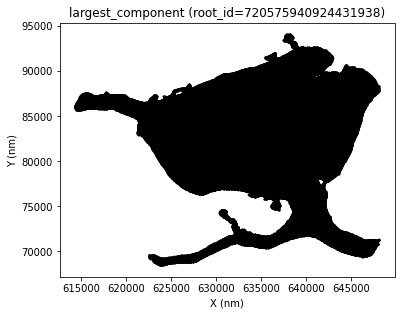


Loading mesh for root ID 720575940890018996...


- Mesh has 1916857 vertices and 3818462 faces
Watertight: False
Signed volume (nm³): 10512498495528.166
Convex hull volume (nm³): 19932450679890.977
🔧 Attempting to fill holes...
Patching holes...
Patched 252 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [17826, 2636, 662] (root_id=720575940890018996) → Volume: 2316.285 µm³


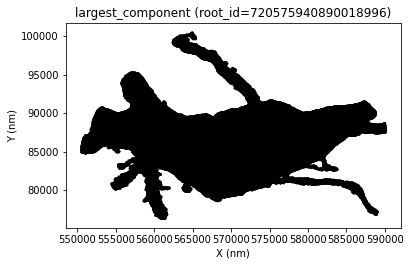


Loading mesh for root ID 720575940917098044...


- Mesh has 1370255 vertices and 2722713 faces
Watertight: False
Signed volume (nm³): -1395832711678.6665
Convex hull volume (nm³): 7177575261408.054
🔧 Attempting to fill holes...
Patching holes...
Patched 235 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [17745, 2179, 2624] (root_id=720575940917098044) → Volume: 1751.343 µm³


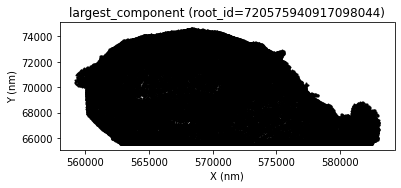


Loading mesh for root ID 720575940888731665...


- Mesh has 1827340 vertices and 3635757 faces
Watertight: False
Signed volume (nm³): -7198488045437.0
Convex hull volume (nm³): 8905966873204.365
🔧 Attempting to fill holes...
Patching holes...
Patched 339 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [19862, 2661, 2076] (root_id=720575940888731665) → Volume: 1708.822 µm³


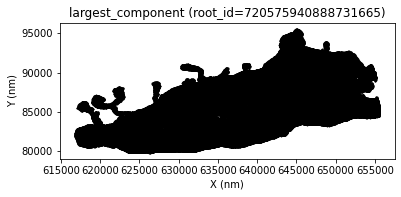


Loading mesh for root ID 720575940892103010...


- Mesh has 1477358 vertices and 2942623 faces
Watertight: False
Signed volume (nm³): 1195697593627.6665
Convex hull volume (nm³): 17272964960328.184
🔧 Attempting to fill holes...
Patching holes...
Patched 9 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [21637, 2347, 2470] (root_id=720575940892103010) → Volume: 2355.099 µm³


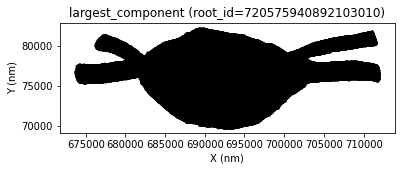

In [25]:
pn_somavolume=[]
for coord, root_id in results:
    volume=compute_soma_volume_and_plot(coord, root_id)
    pn_soma_volume.append(volume)

In [16]:
indices_to_delete = [3,7,14,26,28,31]  # remove 'b' and 'd'

# Sort indices in reverse order and delete
for i in sorted(indices_to_delete, reverse=True):
    del pn_soma_volume[i]

print(pn_soma_volume)



[852.8376782113126, 681.2597076107082, 1037.8485616988958, 892.4998427928541, 975.084609459625, 535.751823163, 703.022463672375, 1024.578561803427, 1039.944270333125, 902.6264085058463, 1073.77219861369, 670.5755063130966, 1098.1522686295884, 983.3915431957969, 793.5478357847187, 751.5434092106563, 858.3106502939401, 647.4891036895676, 1100.4099040478852, 571.105028068375, 616.4341938523958, 1202.1109188339583, 929.2362237335728, 899.6745964718333, 1198.0671280974582, 535.8028093444583, 949.8316924071875, 881.7663668946875, 1017.5727902509167, 752.2104456991797, 1090.3014058039582, 655.7929466374375, 926.9303702362447, 537.1861576842291, 904.0158589556354, 843.1920755130989, 818.9923394361666, 1427.6190838088958, 1044.456466271073, 675.6694763252813, 639.3161816883281, 995.6897853563906, 682.4848195567656, 1131.705535168078, 1795.5424298418645, 607.406469340039]


In [46]:
in_somavolume=pn_soma_volume

In [47]:
in_somavolume=in_somavolume[0:46]

In [48]:
in_somavolume

[852.8376782113126,
 681.2597076107082,
 1037.8485616988958,
 892.4998427928541,
 975.084609459625,
 535.751823163,
 703.022463672375,
 1024.578561803427,
 1039.944270333125,
 902.6264085058463,
 1073.77219861369,
 670.5755063130966,
 1098.1522686295884,
 983.3915431957969,
 793.5478357847187,
 751.5434092106563,
 858.3106502939401,
 647.4891036895676,
 1100.4099040478852,
 571.105028068375,
 616.4341938523958,
 1202.1109188339583,
 929.2362237335728,
 899.6745964718333,
 1198.0671280974582,
 535.8028093444583,
 949.8316924071875,
 881.7663668946875,
 1017.5727902509167,
 752.2104456991797,
 1090.3014058039582,
 655.7929466374375,
 926.9303702362447,
 537.1861576842291,
 904.0158589556354,
 843.1920755130989,
 818.9923394361666,
 1427.6190838088958,
 1044.456466271073,
 675.6694763252813,
 639.3161816883281,
 995.6897853563906,
 682.4848195567656,
 1131.705535168078,
 1795.5424298418645,
 607.406469340039]

In [49]:
in_somavolume.remove(1795.5424298418645)
in_somavolume.remove(1427.6190838088958)

In [34]:
pn_somavolume=pn_soma_volume[46:]

In [39]:


pn_somavolume = [item for item in pn_somavolume if item is not None]



In [50]:
pn_somavolume.append(1795.5424298418645)
pn_somavolume.append(1427.6190838088958)

In [51]:
in_somavolume

[852.8376782113126,
 681.2597076107082,
 1037.8485616988958,
 892.4998427928541,
 975.084609459625,
 535.751823163,
 703.022463672375,
 1024.578561803427,
 1039.944270333125,
 902.6264085058463,
 1073.77219861369,
 670.5755063130966,
 1098.1522686295884,
 983.3915431957969,
 793.5478357847187,
 751.5434092106563,
 858.3106502939401,
 647.4891036895676,
 1100.4099040478852,
 571.105028068375,
 616.4341938523958,
 1202.1109188339583,
 929.2362237335728,
 899.6745964718333,
 1198.0671280974582,
 535.8028093444583,
 949.8316924071875,
 881.7663668946875,
 1017.5727902509167,
 752.2104456991797,
 1090.3014058039582,
 655.7929466374375,
 926.9303702362447,
 537.1861576842291,
 904.0158589556354,
 843.1920755130989,
 818.9923394361666,
 1044.456466271073,
 675.6694763252813,
 639.3161816883281,
 995.6897853563906,
 682.4848195567656,
 1131.705535168078,
 607.406469340039]

In [52]:
pn_somavolume

[2158.354419585682,
 2995.422534075594,
 1402.0754520387707,
 1557.9482832691353,
 1450.2927981658852,
 2531.166905253625,
 2403.953635026208,
 2462.6072178397812,
 2268.2726337880986,
 1799.1671618820208,
 2351.3779874601873,
 2365.5460974279245,
 1761.5332733096118,
 1670.5511596850572,
 1859.138034937888,
 1905.8594504026353,
 1915.57553629875,
 2075.5292164658126,
 1733.245153203802,
 1482.2809045587187,
 1585.433602310625,
 2070.7825217245627,
 2359.0550730950627,
 2283.985789217958,
 2199.947336350344,
 2316.284887342844,
 1751.3429159631353,
 1708.8215446782604,
 2355.0991009981876,
 1795.5424298418645,
 1427.6190838088958]

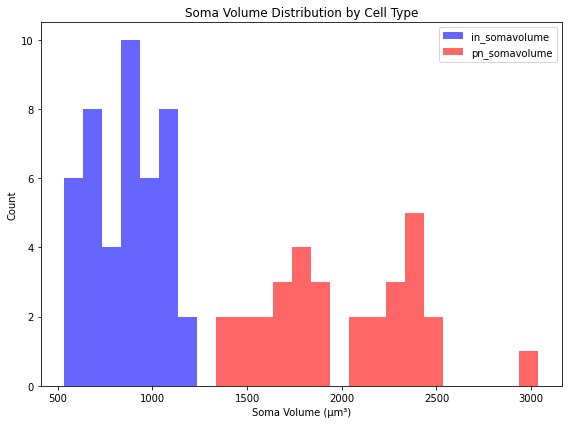

In [66]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
# in_somavolume = [...]
# pn_somavolume = [...]

# Combine data to find global range
all_data = in_somavolume + pn_somavolume
bin_size = 100
min_val = min(all_data)
max_val = max(all_data)
bins = np.arange(min_val, max_val + bin_size, bin_size)

# Plot
plt.figure(figsize=(8, 6))
plt.hist(in_somavolume, bins=bins, color='blue', alpha=0.6, label='in_somavolume')
plt.hist(pn_somavolume, bins=bins, color='red', alpha=0.6, label='pn_somavolume')

plt.xlabel('Soma Volume (µm³)')
plt.ylabel('Count')
plt.title('Soma Volume Distribution by Cell Type')
plt.legend()
plt.tight_layout()

# 🔽 Save to PNG
plt.savefig("soma_volume_histogram.png", dpi=300)

plt.show()


In [64]:
plt.savefig("soma_volume_histogram.png", dpi=300)


<Figure size 432x288 with 0 Axes>

In [6]:
# Libraries
import caveclient
import subprocess
import json
import numpy as np
import matplotlib.pyplot as plt
# Setup caveclient
client = caveclient.CAVEclient("wclee_mouse_spinalcord_cltmr", ) #server_address='https://global.daf-apis.com')

In [7]:
pn_df = client.materialize.query_table('all_neuron_label', filter_equal_dict = {'tag': 'p'})

Query was executed using streaming via CSV, which can mangle types. Please upgrade to caveclient > 8.0.0 to avoid type mangling. Because you may have been affected by mangled types, this change is breaking, but it should provide an improved experience.


In [8]:
superficial_pn = pn_df[pn_df['pt_position'].apply(lambda coord: coord[1] < 4000)]

In [9]:
superficial_pn

,id,created,superceded_id,valid,tag,pt_supervoxel_id,pt_root_id,pt_position
0,2662,2025-06-25 19:26:30.723067+00:00,NaN,t,p,76913107179542244,720575940899779727,"[21958, 2308, 2261]"
1,2663,2025-06-25 19:26:30.723744+00:00,NaN,t,p,76842738569552584,720575940888561868,"[21576, 2354, 2436]"
2,2679,2025-06-25 23:11:08.446582+00:00,NaN,t,p,73324301629119450,720575940918311989,"[8943, 2467, 2972]"
3,2696,2025-06-25 23:11:08.699716+00:00,NaN,t,p,82894724775685239,720575940875863357,"[43651, 3371, 1203]"
4,2712,2025-06-25 23:11:08.895338+00:00,NaN,t,p,73535613080578760,720575940927796016,"[9633, 3120, 1219]"
5,2677,2025-06-25 23:11:08.414109+00:00,NaN,t,p,82824356568335590,720575940902401208,"[43341, 3453, 2176]"
6,2708,2025-06-25 23:11:08.847854+00:00,NaN,t,p,76350225408769910,720575940886290596,"[19801, 2613, 1251]"
7,2667,2025-06-25 23:11:08.267433+00:00,NaN,t,p,81065069043119138,720575940964370854,"[37041, 3108, 1790]"
8,2666,2025-06-25 23:11:08.253838+00:00,NaN,t,p,82050231461686839,720575940893329739,"[40673, 3103, 1892]"
9,2675,2025-06-25 23:11:08.386099+00:00,NaN,t,p,74520708255985251,720575940892250110,"[13304, 2866, 4018]"


In [79]:
pn_id_list = list(zip(superficial_pn['pt_position'], superficial_pn['pt_root_id']))


In [80]:
pn_id_list

[(array([21958,  2308,  2261]), 720575940899779727),
 (array([21576,  2354,  2436]), 720575940892103010),
 (array([33944,  2830,   457]), 720575940884015788),
 (array([23718,  2487,   236]), 720575940921478163),
 (array([40673,  3103,  1892]), 720575940903113149),
 (array([37041,  3108,  1790]), 720575940869352923),
 (array([26998,  2358,  1654]), 720575940887194266),
 (array([18262,  2342,  1860]), 720575940881974650),
 (array([17861,  2655,   713]), 720575940890018996),
 (array([22364,  2792,   812]), 720575940865160474),
 (array([34789,  2792,   906]), 720575940963340820),
 (array([36293,  2701,  3171]), 720575940881844049),
 (array([13304,  2866,  4018]), 720575940882393805),
 (array([10527,  2648,  1282]), 720575940886574602),
 (array([43341,  3453,  2176]), 720575940885287873),
 (array([28280,  2523,  1731]), 720575940928281596),
 (array([8943, 2467, 2972]), 720575940868396952),
 (array([29535,  2433,  3983]), 720575940901717479),
 (array([13822,  2913,  3870]), 72057594088684148


Loading mesh for root ID 720575940899779727...
- Mesh has 851934 vertices and 1691656 faces
Watertight: False
Signed volume (nm³): 1290315947833.1665
Convex hull volume (nm³): 6347493062767.274
🔧 Attempting to fill holes...
Patching holes...
Patched 9 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [21958  2308  2261] (root_id=720575940899779727) → Volume: 1435.500 µm³


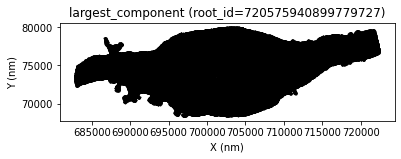


Loading mesh for root ID 720575940892103010...
- Mesh has 1477358 vertices and 2942623 faces
Watertight: False
Signed volume (nm³): 1306330552602.5
Convex hull volume (nm³): 17624412658184.566
🔧 Attempting to fill holes...
Patching holes...
Patched 11 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [21576  2354  2436] (root_id=720575940892103010) → Volume: 2356.114 µm³


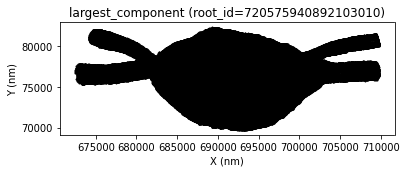


Loading mesh for root ID 720575940884015788...
- Mesh has 886569 vertices and 1756974 faces
Watertight: False
Signed volume (nm³): -1292321251.8333333
Convex hull volume (nm³): 9992534124485.807
🔧 Attempting to fill holes...
Patching holes...
Patched 6 holes
Fixing degeneracies and intersections
Patching holes...
Patched 1 holes
Performing final check...
Watertight after PyMeshFix: False
⚠️ Still not watertight after repair — using convex hull.
❌ Error processing soma 720575940884015788: local variable 'volume_um3' referenced before assignment

Loading mesh for root ID 720575940921478163...
- Mesh has 1394618 vertices and 2775055 faces
Watertight: False
Signed volume (nm³): 3468417823917.5
Convex hull volume (nm³): 9575736157975.217
🔧 Attempting to fill holes...
Patching holes...
Patched 6 holes
Fixing degeneracies and intersections
Patching holes...
Patched 1 holes
Performing final check...
Watertight after PyMeshFix: False
⚠️ Still not watertight after repair — using convex hull.
❌ 

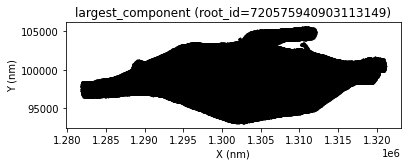


Loading mesh for root ID 720575940869352923...
- Mesh has 2816428 vertices and 5612311 faces
Watertight: False
Signed volume (nm³): -5037785232957.0
Convex hull volume (nm³): 14672346895014.947
🔧 Attempting to fill holes...
Patching holes...
Patched 11 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [37041  3108  1790] (root_id=720575940869352923) → Volume: 2521.850 µm³


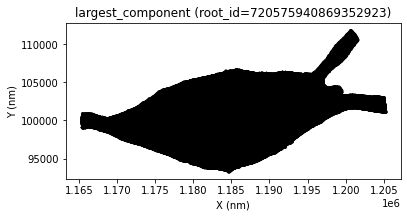


Loading mesh for root ID 720575940887194266...
- Mesh has 990178 vertices and 1973276 faces
Watertight: False
Signed volume (nm³): 767991214245.8333
Convex hull volume (nm³): 9546567747036.21
🔧 Attempting to fill holes...
Patching holes...
Patched 19 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [26998  2358  1654] (root_id=720575940887194266) → Volume: 1558.428 µm³


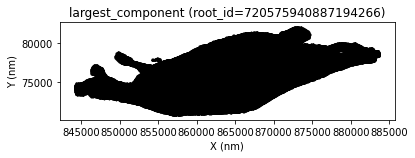


Loading mesh for root ID 720575940881974650...
- Mesh has 1944872 vertices and 3872576 faces
Watertight: False
Signed volume (nm³): -3473565187937.6665
Convex hull volume (nm³): 16403477126017.709
🔧 Attempting to fill holes...
Patching holes...
Patched 30 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [18262  2342  1860] (root_id=720575940881974650) → Volume: 1801.763 µm³


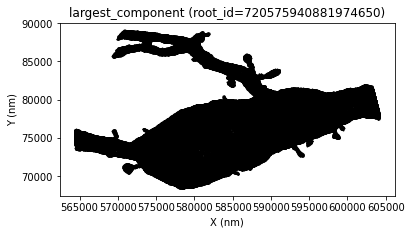


Loading mesh for root ID 720575940890018996...
- Mesh has 1916857 vertices and 3818462 faces
Watertight: False
Signed volume (nm³): 11948832212164.5
Convex hull volume (nm³): 21168476798451.164
🔧 Attempting to fill holes...
Patching holes...
Patched 250 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [17861  2655   713] (root_id=720575940890018996) → Volume: 2317.163 µm³


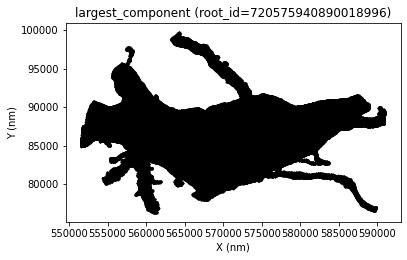


Loading mesh for root ID 720575940865160474...
- Mesh has 612728 vertices and 1217329 faces
Watertight: False
Signed volume (nm³): 5831286787829.666
Convex hull volume (nm³): 22810629012362.094
🔧 Attempting to fill holes...
Patching holes...
Patched 11 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [22364  2792   812] (root_id=720575940865160474) → Volume: 2377.670 µm³


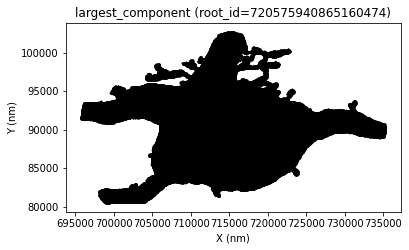


Loading mesh for root ID 720575940963340820...
- Mesh has 872644 vertices and 1733852 faces
Watertight: False
Signed volume (nm³): 1666188442107.1665
Convex hull volume (nm³): 10332478587932.309
🔧 Attempting to fill holes...
Patching holes...
Patched 255 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [34789  2792   906] (root_id=720575940963340820) → Volume: 2077.843 µm³


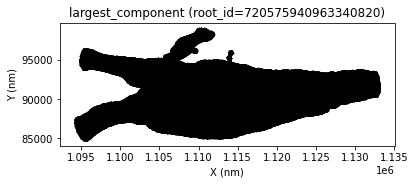


Loading mesh for root ID 720575940881844049...


- Mesh has 1756678 vertices and 3498096 faces
Watertight: False
Signed volume (nm³): -3007468195030.6665
Convex hull volume (nm³): 18254665577545.18
🔧 Attempting to fill holes...
Patching holes...
Patched 36 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [36293  2701  3171] (root_id=720575940881844049) → Volume: 1337.671 µm³


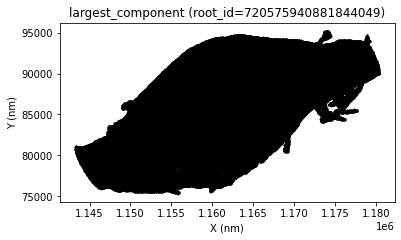


Loading mesh for root ID 720575940882393805...
- Mesh has 1346786 vertices and 2664053 faces
Watertight: False
Signed volume (nm³): -20312572704251.832
Convex hull volume (nm³): 9705122930664.273
🔧 Attempting to fill holes...
Patching holes...
Patched 35 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [13304  2866  4018] (root_id=720575940882393805) → Volume: 1404.697 µm³


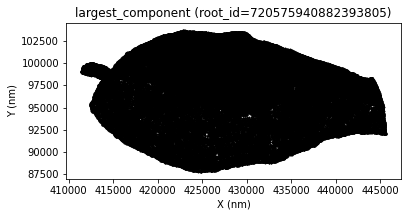


Loading mesh for root ID 720575940886574602...
- Mesh has 1156859 vertices and 2299223 faces
Watertight: False
Signed volume (nm³): 40134064451.33333
Convex hull volume (nm³): 10503600498257.377
🔧 Attempting to fill holes...
Patching holes...
Patched 34 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [10527  2648  1282] (root_id=720575940886574602) → Volume: 2146.878 µm³


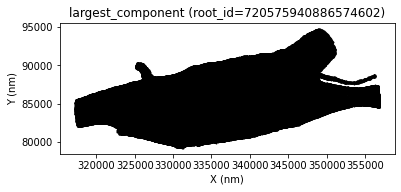


Loading mesh for root ID 720575940885287873...


- Mesh has 1259811 vertices and 2499493 faces
Watertight: False
Signed volume (nm³): -10167925952094.332
Convex hull volume (nm³): 12396879476180.502
🔧 Attempting to fill holes...
Patching holes...
Patched 43 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [43341  3453  2176] (root_id=720575940885287873) → Volume: 1844.358 µm³


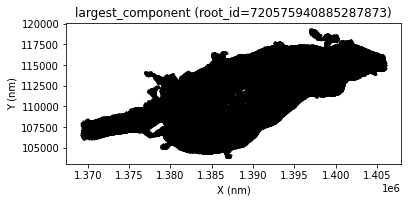


Loading mesh for root ID 720575940928281596...


- Mesh has 586529 vertices and 1166640 faces
Watertight: False
Signed volume (nm³): -855525780691.0
Convex hull volume (nm³): 7568674900081.58
🔧 Attempting to fill holes...
Patching holes...
Patched 6 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [28280  2523  1731] (root_id=720575940928281596) → Volume: 1068.140 µm³


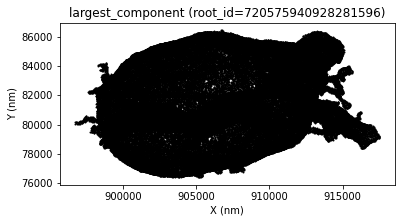


Loading mesh for root ID 720575940868396952...
- Mesh has 1768960 vertices and 3516601 faces
Watertight: False
Signed volume (nm³): 3386041315455.833
Convex hull volume (nm³): 16543775334078.71
🔧 Attempting to fill holes...
Patching holes...
Patched 8 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [8943 2467 2972] (root_id=720575940868396952) → Volume: 3023.563 µm³


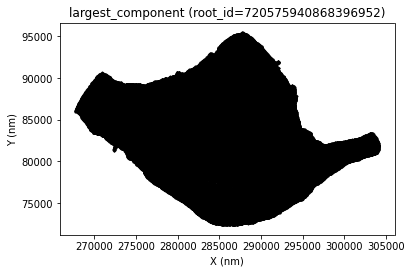


Loading mesh for root ID 720575940901717479...
- Mesh has 1172502 vertices and 2329908 faces
Watertight: False
Signed volume (nm³): -1152009431404.1665
Convex hull volume (nm³): 11160557986707.172
🔧 Attempting to fill holes...
Patching holes...
Patched 3 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [29535  2433  3983] (root_id=720575940901717479) → Volume: 1445.555 µm³


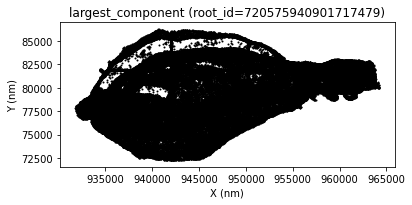


Loading mesh for root ID 720575940886841481...


- Mesh has 1130527 vertices and 2248241 faces
Watertight: False
Signed volume (nm³): -1020085137799.1666
Convex hull volume (nm³): 18469494978213.715
🔧 Attempting to fill holes...
Patching holes...
Patched 14 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [13822  2913  3870] (root_id=720575940886841481) → Volume: 2345.578 µm³


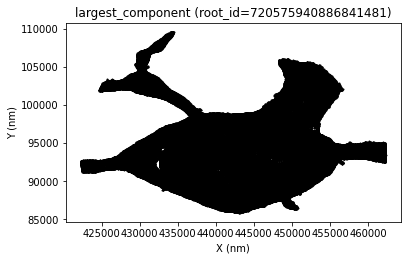


Loading mesh for root ID 720575940896702138...
- Mesh has 953488 vertices and 1895463 faces
Watertight: False
Signed volume (nm³): 1399441094825.5
Convex hull volume (nm³): 16818899227895.246
🔧 Attempting to fill holes...
Patching holes...
Patched 60 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [5689 2462 2592] (root_id=720575940896702138) → Volume: 1760.173 µm³


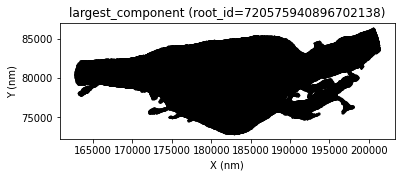


Loading mesh for root ID 720575940890704372...
- Mesh has 702259 vertices and 1392399 faces
Watertight: False
Signed volume (nm³): 1057909200541.0
Convex hull volume (nm³): 8246959855071.157
🔧 Attempting to fill holes...
Patching holes...
Patched 175 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [6483 2370 1819] (root_id=720575940890704372) → Volume: 2363.062 µm³


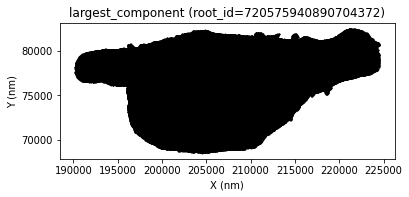


Loading mesh for root ID 720575940905050934...
- Mesh has 1023106 vertices and 2031708 faces
Watertight: False
Signed volume (nm³): -434868135633.3333
Convex hull volume (nm³): 13636243793011.777
🔧 Attempting to fill holes...
Patching holes...
Patched 16 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [25416  2229  2938] (root_id=720575940905050934) → Volume: 1864.855 µm³


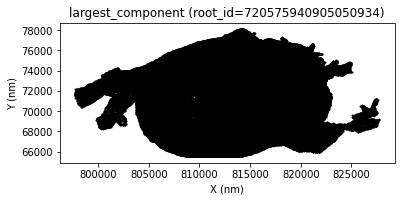


Loading mesh for root ID 720575940913491825...
- Mesh has 1078615 vertices and 2145962 faces
Watertight: False
Signed volume (nm³): -2096001557649.5
Convex hull volume (nm³): 10166387284277.107
🔧 Attempting to fill holes...
Patching holes...
Patched 297 holes
Fixing degeneracies and intersections
Patching holes...
Patched 1 holes
Performing final check...


Watertight after PyMeshFix: False
⚠️ Still not watertight after repair — using convex hull.
❌ Error processing soma 720575940913491825: local variable 'volume_um3' referenced before assignment

Loading mesh for root ID 720575940898432765...


- Mesh has 1347043 vertices and 2681838 faces
Watertight: False
Signed volume (nm³): -7206691967719.333
Convex hull volume (nm³): 15622084655544.523
🔧 Attempting to fill holes...
Patching holes...
Patched 117 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [29367  2807   368] (root_id=720575940898432765) → Volume: 1915.128 µm³


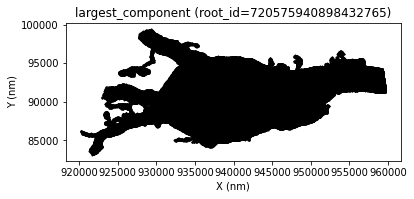


Loading mesh for root ID 720575940888731665...
- Mesh has 1827340 vertices and 3635757 faces
Watertight: False
Signed volume (nm³): -1400514092387.8333
Convex hull volume (nm³): 9284530462870.262
🔧 Attempting to fill holes...
Patching holes...
Patched 348 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [19953  2666  2072] (root_id=720575940888731665) → Volume: 1735.105 µm³


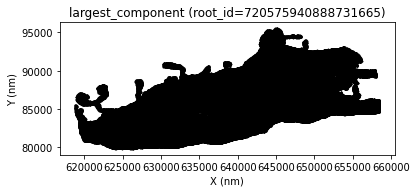


Loading mesh for root ID 720575940902518994...
- Mesh has 1295825 vertices and 2574355 faces
Watertight: False
Signed volume (nm³): 9924101175811.332
Convex hull volume (nm³): 10602088660951.582
🔧 Attempting to fill holes...
Patching holes...
Patched 230 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [20000  2277  2229] (root_id=720575940902518994) → Volume: 2429.974 µm³


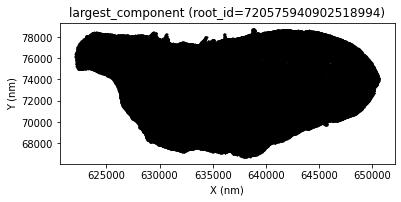


Loading mesh for root ID 720575940879773686...
- Mesh has 1109530 vertices and 2206865 faces
Watertight: False
Signed volume (nm³): -3220635485295.1665
Convex hull volume (nm³): 6212413424306.339
🔧 Attempting to fill holes...
Patching holes...
Patched 6 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [17785  2905   250] (root_id=720575940879773686) → Volume: 1652.172 µm³


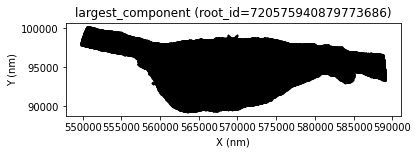


Loading mesh for root ID 720575940884939979...
- Mesh has 1291474 vertices and 2571558 faces
Watertight: False
Signed volume (nm³): 1000097573348.5
Convex hull volume (nm³): 10220111383876.229
🔧 Attempting to fill holes...
Patching holes...
Patched 145 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [28653  2517  2583] (root_id=720575940884939979) → Volume: 2065.190 µm³


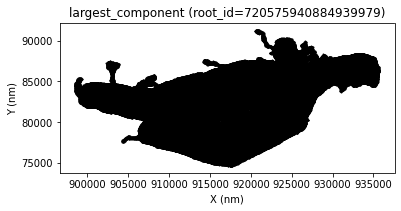


Loading mesh for root ID 720575940880850833...


- Mesh has 1355298 vertices and 2700095 faces
Watertight: False
Signed volume (nm³): -4249094679291.333
Convex hull volume (nm³): 7727892346328.699
🔧 Attempting to fill holes...
Patching holes...
Patched 104 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [34054  3109   377] (root_id=720575940880850833) → Volume: 1774.037 µm³


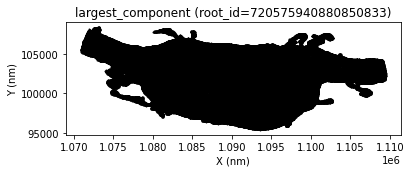


Loading mesh for root ID 720575940915676096...
- Mesh has 1715876 vertices and 3405056 faces
Watertight: False
Signed volume (nm³): 16986427055726.666
Convex hull volume (nm³): 6166557640530.575
🔧 Attempting to fill holes...
Patching holes...
Patched 26 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [23578  2619  1257] (root_id=720575940915676096) → Volume: 2398.243 µm³


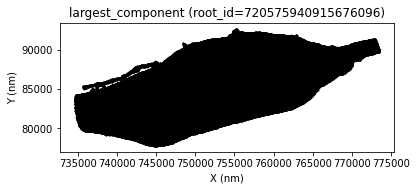


Loading mesh for root ID 720575940925790278...


- Mesh has 884891 vertices and 1762111 faces
Watertight: False
Signed volume (nm³): -2108029478272.0
Convex hull volume (nm³): 16738069200246.549
🔧 Attempting to fill holes...
Patching holes...
Patched 11 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [25142  2570  2442] (root_id=720575940925790278) → Volume: 1791.748 µm³


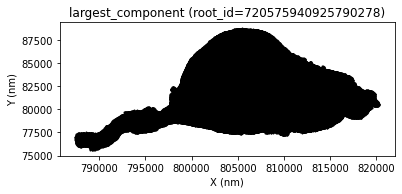


Loading mesh for root ID 720575940898677394...
- Mesh has 694555 vertices and 1379205 faces
Watertight: False
Signed volume (nm³): 11021504120506.5
Convex hull volume (nm³): 18318267240550.816
🔧 Attempting to fill holes...
Patching holes...
Patched 41 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [30196  2494   713] (root_id=720575940898677394) → Volume: 1925.205 µm³


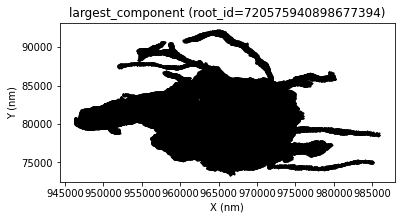


Loading mesh for root ID 720575940914014910...
- Mesh has 1156938 vertices and 2299745 faces
Watertight: False
Signed volume (nm³): 860652734471.5
Convex hull volume (nm³): 15796142064726.883
🔧 Attempting to fill holes...
Patching holes...
Patched 636 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [7905 2349 1900] (root_id=720575940914014910) → Volume: 2373.307 µm³


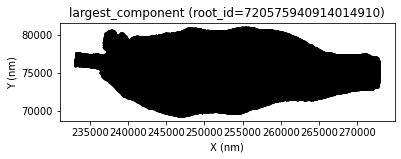


Loading mesh for root ID 720575940897341698...
- Mesh has 697361 vertices and 1382230 faces
Watertight: False
Signed volume (nm³): 1833092167359.8333
Convex hull volume (nm³): 11948032512004.19
🔧 Attempting to fill holes...
Patching holes...
Patched 23 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [43651  3371  1203] (root_id=720575940897341698) → Volume: 1732.819 µm³


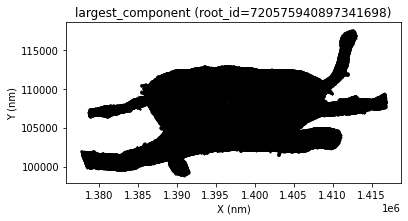


Loading mesh for root ID 720575940889952699...
- Mesh has 803030 vertices and 1581881 faces
Watertight: False
Signed volume (nm³): -6683283197877.5
Convex hull volume (nm³): 10674656747179.367
🔧 Attempting to fill holes...
Patching holes...
Patched 74 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [18634  2416  1086] (root_id=720575940889952699) → Volume: 2321.543 µm³


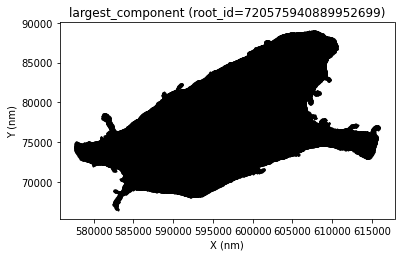


Loading mesh for root ID 720575940895281326...


- Mesh has 785552 vertices and 1563495 faces
Watertight: False
Signed volume (nm³): 1778629277814.8333
Convex hull volume (nm³): 10637644068674.84
🔧 Attempting to fill holes...
Patching holes...
Patched 6 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [36999  2825  4021] (root_id=720575940895281326) → Volume: 777.150 µm³


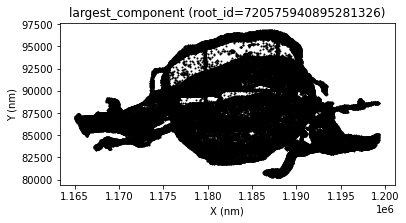


Loading mesh for root ID 720575940909802419...
- Mesh has 671885 vertices and 1335511 faces
Watertight: False
Signed volume (nm³): -13067008017686.832
Convex hull volume (nm³): 12664355108752.371
🔧 Attempting to fill holes...
Patching holes...
Patched 86 holes
Fixing degeneracies and intersections
Patching holes...
Patched 1 holes
Performing final check...


Watertight after PyMeshFix: False
⚠️ Still not watertight after repair — using convex hull.
❌ Error processing soma 720575940909802419: local variable 'volume_um3' referenced before assignment

Loading mesh for root ID 720575940883900444...


- Mesh has 468398 vertices and 928160 faces
Watertight: False
Signed volume (nm³): -1060635736216.5
Convex hull volume (nm³): 20098791016696.453
🔧 Attempting to fill holes...
Patching holes...
Patched 16 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [34082  2929   995] (root_id=720575940883900444) → Volume: 1886.309 µm³


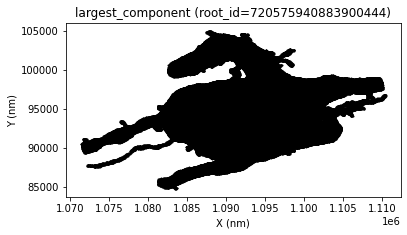


Loading mesh for root ID 720575940917098044...
- Mesh has 1370255 vertices and 2722713 faces
Watertight: False
Signed volume (nm³): -690590089420.5
Convex hull volume (nm³): 7229981430778.106
🔧 Attempting to fill holes...
Patching holes...
Patched 226 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [17753  2177  2587] (root_id=720575940917098044) → Volume: 1761.753 µm³


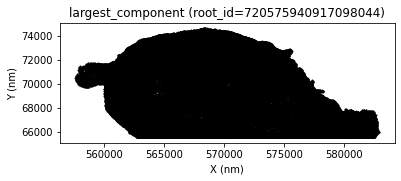


Loading mesh for root ID 720575940894664201...


- Mesh has 956513 vertices and 1901379 faces
Watertight: False
Signed volume (nm³): 4801094398794.833
Convex hull volume (nm³): 9105771811161.318
🔧 Attempting to fill holes...
Patching holes...
Patched 18 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [22764  2181  1856] (root_id=720575940894664201) → Volume: 1414.823 µm³


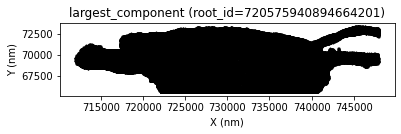


Loading mesh for root ID 720575940882103072...


- Mesh has 1444459 vertices and 2877420 faces
Watertight: False
Signed volume (nm³): 2104616161696.0
Convex hull volume (nm³): 7232591531556.261
🔧 Attempting to fill holes...
Patching holes...
Patched 9 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [31305  2441  3678] (root_id=720575940882103072) → Volume: 1292.167 µm³


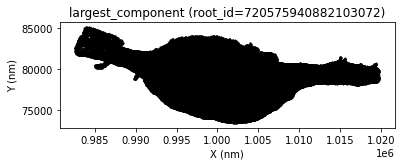


Loading mesh for root ID 720575940883198167...
- Mesh has 1076643 vertices and 2145901 faces
Watertight: False
Signed volume (nm³): 10740765801221.0
Convex hull volume (nm³): 9014784544448.486
🔧 Attempting to fill holes...
Patching holes...
Patched 4 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [30313  2701  1640] (root_id=720575940883198167) → Volume: 1606.313 µm³


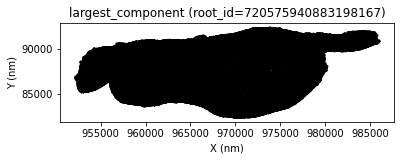


Loading mesh for root ID 720575940890939713...


- Mesh has 1169011 vertices and 2325273 faces
Watertight: False
Signed volume (nm³): 6489620502874.0
Convex hull volume (nm³): 11573637634337.932
🔧 Attempting to fill holes...
Patching holes...
Patched 10 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [24252  2246  3590] (root_id=720575940890939713) → Volume: 1424.455 µm³


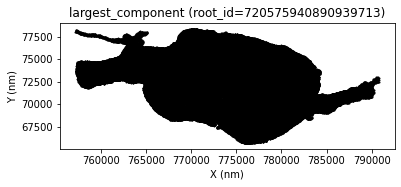


Loading mesh for root ID 720575940894563284...
- Mesh has 702374 vertices and 1397142 faces
Watertight: False
Signed volume (nm³): 183012336182.8333
Convex hull volume (nm³): 16662607120314.541
🔧 Attempting to fill holes...
Patching holes...
Patched 17 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [31434  2687   859] (root_id=720575940894563284) → Volume: 1484.084 µm³


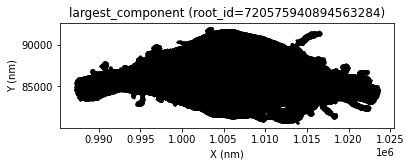


Loading mesh for root ID 720575940924431938...
- Mesh has 843808 vertices and 1678570 faces
Watertight: False
Signed volume (nm³): -4745858190767.333
Convex hull volume (nm³): 12202502494159.09
🔧 Attempting to fill holes...
Patching holes...
Patched 212 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [19801  2613  1251] (root_id=720575940924431938) → Volume: 2262.034 µm³


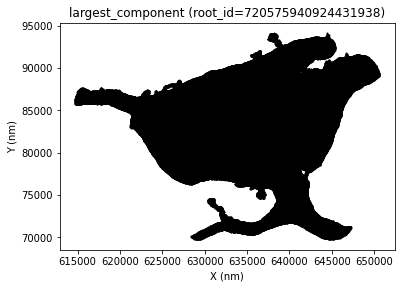


Loading mesh for root ID 720575940917797515...


- Mesh has 415980 vertices and 827391 faces
Watertight: False
Signed volume (nm³): -232772276948.66666
Convex hull volume (nm³): 3404077367929.722
🔧 Attempting to fill holes...
Patching holes...
Patched 173 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [31369  2595  1871] (root_id=720575940917797515) → Volume: 715.201 µm³


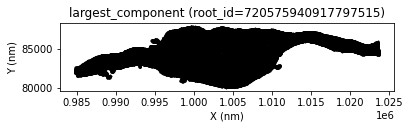


Loading mesh for root ID 720575940851357043...


- Mesh has 340270 vertices and 673954 faces
Watertight: False
Signed volume (nm³): -1638562331131.6665
Convex hull volume (nm³): 9309578716682.076
🔧 Attempting to fill holes...
Patching holes...
Patched 192 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [28152  2399  1863] (root_id=720575940851357043) → Volume: 693.520 µm³


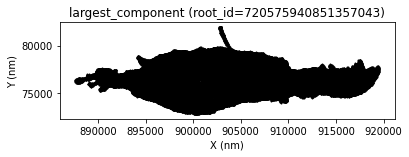


Loading mesh for root ID 720575940894637107...


- Mesh has 632938 vertices and 1259575 faces
Watertight: False
Signed volume (nm³): 1916898920541.1665
Convex hull volume (nm³): 14772106777483.518
🔧 Attempting to fill holes...
Patching holes...
Patched 37 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [38793  3157  2047] (root_id=720575940894637107) → Volume: 899.587 µm³


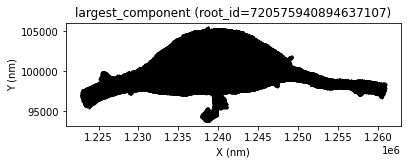


Loading mesh for root ID 720575940883900700...


- Mesh has 1536828 vertices and 3045858 faces
Watertight: False
Signed volume (nm³): 4254566250543.833
Convex hull volume (nm³): 13319861347176.287
🔧 Attempting to fill holes...
Patching holes...
Patched 1008 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [9633 3120 1219] (root_id=720575940883900700) → Volume: 1980.460 µm³


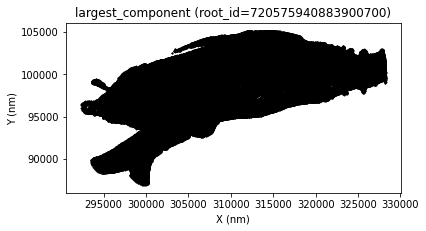


Loading mesh for root ID 720575940930825549...


- Mesh has 1389572 vertices and 2747678 faces
Watertight: False
Signed volume (nm³): -7222704937278.5
Convex hull volume (nm³): 13235061095607.66
🔧 Attempting to fill holes...
Patching holes...
Patched 53 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [46316  3362  1139] (root_id=720575940930825549) → Volume: 1973.837 µm³


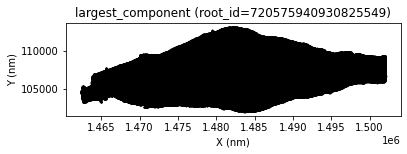


Loading mesh for root ID 720575940898821041...


- Mesh has 1375408 vertices and 2738926 faces
Watertight: False
Signed volume (nm³): 1772132969399.0
Convex hull volume (nm³): 18662018150139.023
🔧 Attempting to fill holes...
Patching holes...
Patched 10 holes
Fixing degeneracies and intersections
Watertight after PyMeshFix: True
✅ Soma at [11903  3126   706] (root_id=720575940898821041) → Volume: 1781.694 µm³


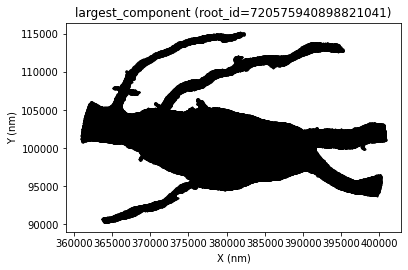

In [81]:
pn_somavolume=[]
for coord, root_id in pn_id_list:
    volume=compute_soma_volume_and_plot(coord, root_id)
    pn_somavolume.append(volume)

In [82]:
pn_somavolume

[1435.5000926035832,
 2356.113895343594,
 None,
 None,
 2402.9453399588956,
 2521.8502494071663,
 1558.4275780554376,
 1801.763275726932,
 2317.1625037306667,
 2377.670233574708,
 2077.8431764201873,
 1337.6709473187316,
 1404.6969807877408,
 2146.877754826531,
 1844.3581924314062,
 1068.1404117936459,
 3023.562594600198,
 1445.5553585203957,
 2345.57793411675,
 1760.172572524979,
 2363.062223488168,
 1864.8553358915299,
 None,
 1915.127863954729,
 1735.1047544460312,
 2429.973766832044,
 1652.17226406375,
 2065.189678543208,
 1774.0371407468126,
 2398.243153078656,
 1791.7475789821665,
 1925.2049129130728,
 2373.3073793236495,
 1732.818749815854,
 2321.542863965177,
 777.1499717475938,
 None,
 1886.3091675203489,
 1761.7529138053126,
 1414.8229327803333,
 1292.1669990198307,
 1606.3130022124376,
 1424.4546544022082,
 1484.0844247130415,
 2262.0336743083126,
 715.2006305502291,
 693.5202732625078,
 899.5866679279583,
 1980.4600585750052,
 1973.836655058052,
 1781.6936325473437]

In [83]:
pn_somavolume = [item for item in pn_somavolume if item is not None]

In [85]:
pn_somavolume.remove(1068.1404117936459)
pn_somavolume.remove(777.1499717475938)
pn_somavolume.remove(693.5202732625078)
pn_somavolume.remove(715.2006305502291)
pn_somavolume.remove(899.5866679279583)

In [1]:
pn_somavolume=[1435.5000926035832,
 2356.113895343594,
 2402.9453399588956,
 2521.8502494071663,
 1558.4275780554376,
 1801.763275726932,
 2317.1625037306667,
 2377.670233574708,
 2077.8431764201873,
 1337.6709473187316,
 1404.6969807877408,
 2146.877754826531,
 1844.3581924314062,
 3023.562594600198,
 1445.5553585203957,
 2345.57793411675,
 1760.172572524979,
 2363.062223488168,
 1864.8553358915299,
 1915.127863954729,
 1735.1047544460312,
 2429.973766832044,
 1652.17226406375,
 2065.189678543208,
 1774.0371407468126,
 2398.243153078656,
 1791.7475789821665,
 1925.2049129130728,
 2373.3073793236495,
 1732.818749815854,
 2321.542863965177,
 1886.3091675203489,
 1761.7529138053126,
 1414.8229327803333,
 1292.1669990198307,
 1606.3130022124376,
 1424.4546544022082,
 1484.0844247130415,
 2262.0336743083126,
 1980.4600585750052,
 1973.836655058052,
 1781.6936325473437]

In [2]:
in_somavolume=[852.8376782113126,
 681.2597076107082,
 1037.8485616988958,
 892.4998427928541,
 975.084609459625,
 535.751823163,
 703.022463672375,
 1024.578561803427,
 1039.944270333125,
 902.6264085058463,
 1073.77219861369,
 670.5755063130966,
 1098.1522686295884,
 983.3915431957969,
 793.5478357847187,
 751.5434092106563,
 858.3106502939401,
 647.4891036895676,
 1100.4099040478852,
 571.105028068375,
 616.4341938523958,
 1202.1109188339583,
 929.2362237335728,
 899.6745964718333,
 1198.0671280974582,
 535.8028093444583,
 949.8316924071875,
 881.7663668946875,
 1017.5727902509167,
 752.2104456991797,
 1090.3014058039582,
 655.7929466374375,
 926.9303702362447,
 537.1861576842291,
 904.0158589556354,
 843.1920755130989,
 818.9923394361666,
 1044.456466271073,
 675.6694763252813,
 639.3161816883281,
 995.6897853563906,
 682.4848195567656,
 1131.705535168078,
 607.406469340039]

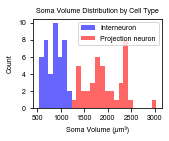

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Example data
# in_somavolume = [...]
# pn_somavolume = [...]

# Combine data to find global range
all_data = in_somavolume + pn_somavolume
bin_size = 100
min_val = min(all_data)
max_val = max(all_data)
bins = np.arange(min_val, max_val + bin_size, bin_size)

# --- Global font settings ---
plt.rcParams['font.family'] = 'Helvetica'
plt.rcParams['font.size'] = 7

# Figure size: 7 cm x 7 cm
cm = 1 / 2.54
plt.figure(figsize=(6 * cm, 5 * cm))

# Plot
plt.hist(in_somavolume, bins=bins, color='blue', alpha=0.6, label='Interneuron')
plt.hist(pn_somavolume, bins=bins, color='red', alpha=0.6, label='Projection neuron')

# Axis labels with font size 7
plt.xlabel('Soma Volume (µm³)', fontsize=7)
plt.ylabel('Count', fontsize=7)

# Optional: match tick label size
plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.title('Soma Volume Distribution by Cell Type', fontsize=7)
plt.legend(fontsize=7)
plt.tight_layout()

# Save as SVG
plt.savefig("soma_volume_histogram.svg", format="svg")

plt.show()
